In [1]:
import pandas as pd

In [2]:
dataset = pd.read_csv("insurance_pre.csv")

In [3]:
dataset = pd.get_dummies(dataset, drop_first = 'true')
dataset = dataset.astype(int)


In [4]:
dataset.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes'], dtype='object')

In [5]:
independent=dataset[['age', 'bmi', 'children', 'sex_male', 'smoker_yes']]

In [6]:
dependent = dataset[['charges']]

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(independent, dependent, test_size=0.30, random_state = 0)

In [8]:
#https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(criterion='poisson', splitter='random',max_features= 'log2',random_state=0)
regressor = regressor.fit(X_train, Y_train)

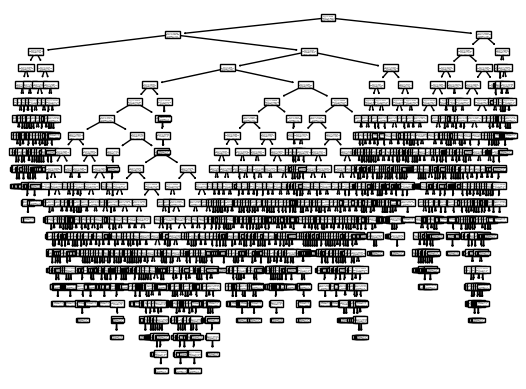

In [9]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [10]:
y_pred = regressor.predict(X_test)

In [11]:
from sklearn.metrics import r2_score
r2_score = r2_score(Y_test, y_pred)

In [12]:
r2_score

0.6833989633538271